In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer
from difflib import get_close_matches

In [3]:
df = pd.read_csv('master_dataset_final.csv')


In [4]:
def create_soup(x):
    features = []
    for col in ['main_director', 'title', 'genres', 'keywords', 'overview']:
        if col in x and pd.notna(x[col]):
            features.append(str(x[col]))
    return ' '.join(features)
df['soup'] = df.apply(create_soup, axis=1)    

In [5]:
ps = PorterStemmer()
def stem(text):
    return ' '.join([ps.stem(i) for i in text.split()])

df['soup'] = df['soup'].apply(stem)

In [6]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(df['soup']).toarray()


In [7]:
similarity = cosine_similarity(vectors)

In [8]:
def recommend(movie_title, threshold=0.1, top_n=10):
    if movie_title not in df['title'].values:
        matches = get_close_matches(movie_title, df['title'].values, n=1, cutoff=0.6)
        if matches:
            print(f"Movie '{movie_title}' not found. Showing recommendations for closest match '{matches[0]}'.")
            movie_title = matches[0]
        else:
            print(f"Movie '{movie_title}' not found in dataset and no close match available.")
            return

    movie_index = df[df['title'] == movie_title].index[0]
    distances = similarity[movie_index]
    movies_list = [(i, dist) for i, dist in enumerate(distances) if dist > threshold and i != movie_index]

    if not movies_list:
        print(f"No movies similar to '{movie_title}' with similarity > {threshold}.")
        return

    movies_list = sorted(movies_list, reverse=True, key=lambda x: x[1])[:top_n]
    titles = [df.iloc[i[0]].title for i in movies_list]
    scores = [i[1] for i in movies_list]

    print(f"\nTop movies similar to '{movie_title}' (similarity > {threshold}):")
    for t, s in zip(titles, scores):
        print(f"- {t} (Similarity: {s:.2f})")

    plt.figure(figsize=(8, max(4, len(titles)*0.3)))
    plt.barh(titles[::-1], scores[::-1], color='skyblue')
    plt.xlabel('Similarity Score')
    plt.title(f"Movies similar to '{movie_title}'")
    plt.tight_layout()
    plt.show()


Enter a movie name (or 'exit' to quit):  train to busan


Movie 'train to busan' not found. Showing recommendations for closest match 'Train to Busan'.

Top movies similar to 'Train to Busan' (similarity > 0.1):
- Okja (Similarity: 0.22)
- Strangers on a Train (Similarity: 0.22)
- Runaway Train (Similarity: 0.22)
- How to Train Your Dragon (Similarity: 0.22)
- Snowpiercer (Similarity: 0.22)
- Training Day (Similarity: 0.22)
- Death Train (Similarity: 0.22)
- How to Train Your Dragon 2 (Similarity: 0.22)
- The Midnight Meat Train (Similarity: 0.20)


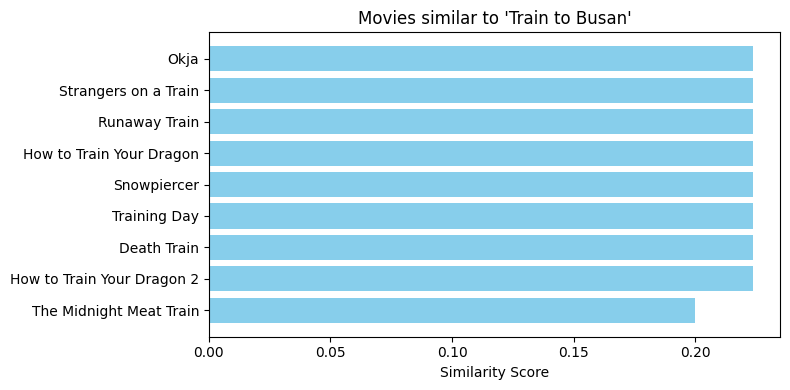

Enter a movie name (or 'exit' to quit):  Wonder women


Movie 'Wonder women' not found. Showing recommendations for closest match 'Wonder Woman'.

Top movies similar to 'Wonder Woman' (similarity > 0.1):
- Moonlight (Similarity: 0.29)
- I Could Never Be Your Woman (Similarity: 0.29)
- The Woman in Red (Similarity: 0.25)
- It's a Wonderful Life (Similarity: 0.25)
- Scent of a Woman (Similarity: 0.25)
- Pretty Woman (Similarity: 0.25)
- Mr. Wonderful (Similarity: 0.25)
- Woman in Gold (Similarity: 0.25)
- Florence Foster Jenkins (Similarity: 0.22)


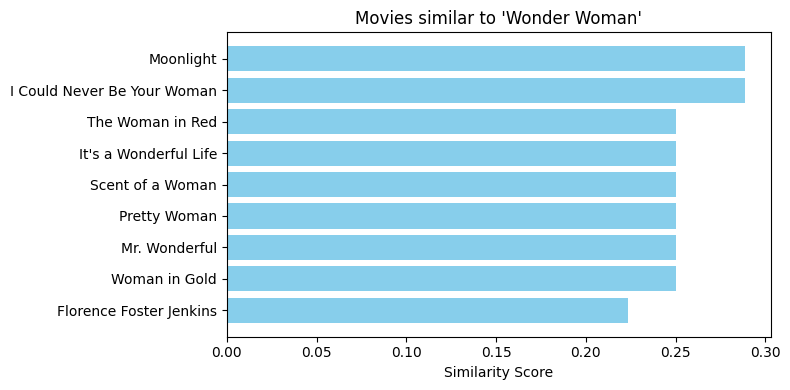

Enter a movie name (or 'exit' to quit):  minions


Movie 'minions' not found. Showing recommendations for closest match 'Minions'.

Top movies similar to 'Minions' (similarity > 0.1):
- Despicable Me 3 (Similarity: 0.67)
- Barely Lethal (Similarity: 0.29)


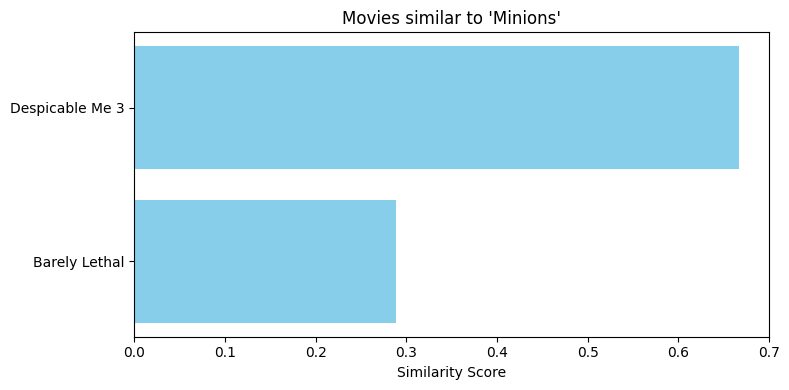

Enter a movie name (or 'exit' to quit):  exit


Exiting the recommender system.


In [10]:
while True:
    user_movie = input("Enter a movie name (or 'exit' to quit): ").strip()
    if user_movie.lower() == 'exit':
        print("Exiting the recommender system.")
        break
    recommend(user_movie)